# Predictive Modeling for Obstetric Diagnostics Using Machine Learning

**Course:** MDSC 6103 – Artificial Intelligence (Machine Learning & Business Intelligence)  
**Student:** Peter Manda  
**Assignment:** Fetal Health Classification Using CTG Data  


## Background

Cardiotocography (CTG) is a clinical monitoring technique used to assess fetal heart rate patterns and uterine contractions during pregnancy and labour. Accurate interpretation of CTG signals is essential for identifying fetal distress and preventing adverse perinatal outcomes. However, manual interpretation is often subjective and may vary between clinicians.

Recent advances in **Artificial Intelligence (AI)** and **Machine Learning (ML)** enable automated analysis of CTG data, improving diagnostic consistency and supporting clinical decision-making.

This notebook applies supervised machine learning techniques to classify fetal health status using two CTG-related datasets. It includes **Exploratory Data Analysis (EDA)**, model training, evaluation, and comparison across multiple machine learning models.


## Study Objectives

- Preprocess and explore CTG-based fetal health datasets.  
- Perform **EDA** including:
  - Data integrity checks (missing values, duplicates)
  - Target class distribution visualization
  - Feature distribution plots
  - Correlation analysis  
- Train multiple machine learning classification models:
  - Logistic Regression  
  - Random Forest  
  - Support Vector Machine (SVM)  
  - K-Nearest Neighbors (KNN)  
- Evaluate performance using clinical evaluation metrics (accuracy, confusion matrix, classification report).  
- Compare predictive performance across the **Fetal Health** and **CTG** datasets.  
- Identify the most clinically reliable diagnostic model for fetal health.


In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Constants
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
def perform_eda(df, target_col, dataset_name):
    print(f"\n{'='*60}")
    print(f"EDA: {dataset_name}")
    print(f"{'='*60}")

    # Data Integrity
    print("\nMissing Values:\n", df.isnull().sum())
    print("\nDuplicate Rows:", df.duplicated().sum())

    # Targeting Variable Distribution
    plt.figure()
    df[target_col].value_counts().plot(kind="bar")
    plt.title(f"{dataset_name} – Target Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

    # Feature Distributions (3 numeric features)
    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    features = [col for col in numeric_cols if col != target_col][:3]

    for feature in features:
        plt.figure()
        sns.histplot(df[feature], kde=True)
        plt.title(f"{dataset_name} – Distribution of {feature}")
        plt.show()

    # Correlation Matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.select_dtypes(include="number").corr(), cmap="coolwarm", annot=True)
    plt.title(f"{dataset_name} – Correlation Matrix")
    plt.show()


Each model has been chosen based on its suitability for the **fetal health classification problem** using CTG data. Below is the reasoning for selecting each model:


### 1. Logistic Regression
- **Reasoning:** Logistic Regression is a simple and interpretable model for binary and multiclass classification.  
- It estimates the probability of class membership and is particularly effective when the relationship between features and the target is **approximately linear in the log-odds**.  
- **Suitability:** Provides insight into feature importance and is a strong baseline model for medical classification tasks.


### 2. Random Forest
- **Reasoning:** Random Forest is an ensemble learning method that constructs multiple decision trees and averages their predictions.  
- It can capture **complex, non-linear relationships** between features and the target variable.  
- **Suitability:** Robust to noisy data, handles imbalanced datasets well (via class weights), and is widely used in biomedical data analysis.


### 3. Support Vector Machine (SVM)
- **Reasoning:** SVM finds the hyperplane that maximally separates classes in feature space, with support for **non-linear separation using kernel functions**.  
- **Suitability:** Effective for high-dimensional datasets, sensitive to class margins, and works well with standardized features.


### 4. K-Nearest Neighbors (KNN)
- **Reasoning:** KNN is a non-parametric, instance-based algorithm that classifies samples based on the labels of their **nearest neighbors** in feature space.  
- **Suitability:** Simple and intuitive, works well when similar CTG feature patterns indicate similar fetal health classes, and can adapt to complex class boundaries.


**Next Step:** Each of these models will be trained and evaluated using the preprocessed CTG datasets. Performance will be assessed using **accuracy, confusion matrices, and classification reports** to identify the most clinically reliable model.


In [3]:
def run_pipeline(df, target_col, dataset_name):
    print(f"\n{'='*65}")
    print(f"DATASET: {dataset_name}")
    print(f"{'='*65}")

    # Keeping only numeric columns
    df = df.select_dtypes(include=[np.number])

    # Dataset info
    print("\nDataset Shape:", df.shape)
    print("\nTarget Distribution:")
    print(df[target_col].value_counts())

    # Feature / Target Split
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y
    )

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define Models
    models = {
        "Logistic Regression": LogisticRegression(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            max_iter=1000
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        "Support Vector Machine": SVC(
            kernel="rbf",
            class_weight="balanced"
        ),
        "K-Nearest Neighbors": KNeighborsClassifier(
            n_neighbors=7
        )
    }

    # Training & Evaluating Models
    for name, model in models.items():
        print(f"\n{name}")
        print("-" * len(name))

        if name == "Random Forest":
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
        else:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)

        print("Accuracy:", accuracy_score(y_test, y_pred))
        print(classification_report(y_test, y_pred))

        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(f"{dataset_name} – {name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()


## Choice of Scaler and Train-Test Split

- **Scaler:** We use **StandardScaler** to standardize features to have mean = 0 and standard deviation = 1.  
  - This is important for distance-based algorithms like **KNN** and **SVM**, which are sensitive to the scale of input features.
  - For tree-based models like **Random Forest**, scaling is not strictly necessary, but using a single scaling method keeps the pipeline consistent.

- **Train-Test Split:** We use a **test_size = 0.2 (80% train, 20% test)** with **stratification on the target variable**.  
  - This ensures the training and testing sets maintain the same class distribution as the original dataset.
  - 80/20 is a common choice providing sufficient data for training while retaining enough for unbiased evaluation.



EDA: Fetal Health Dataset

Missing Values:
 baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                             

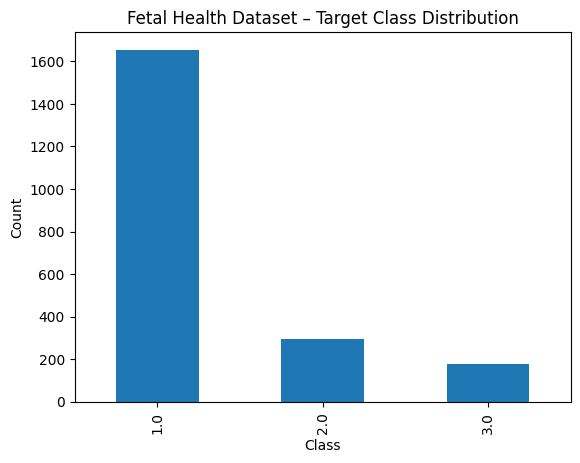

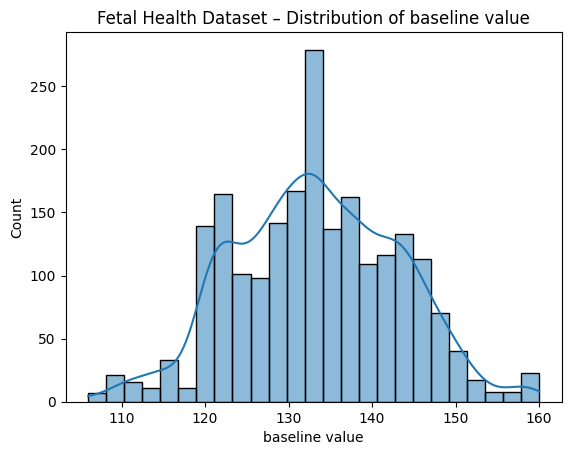

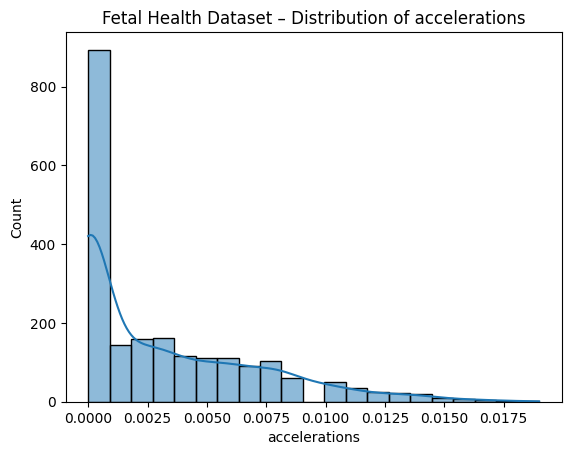

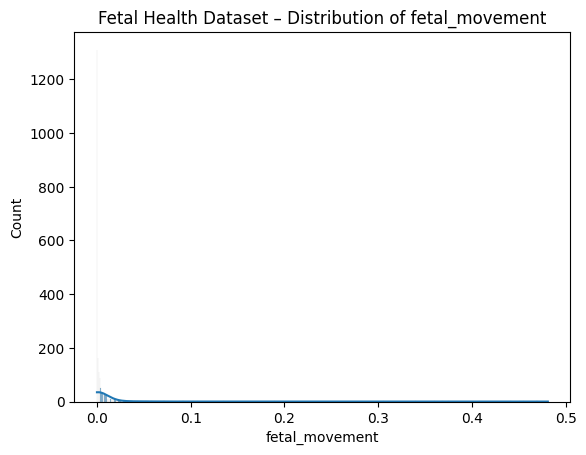

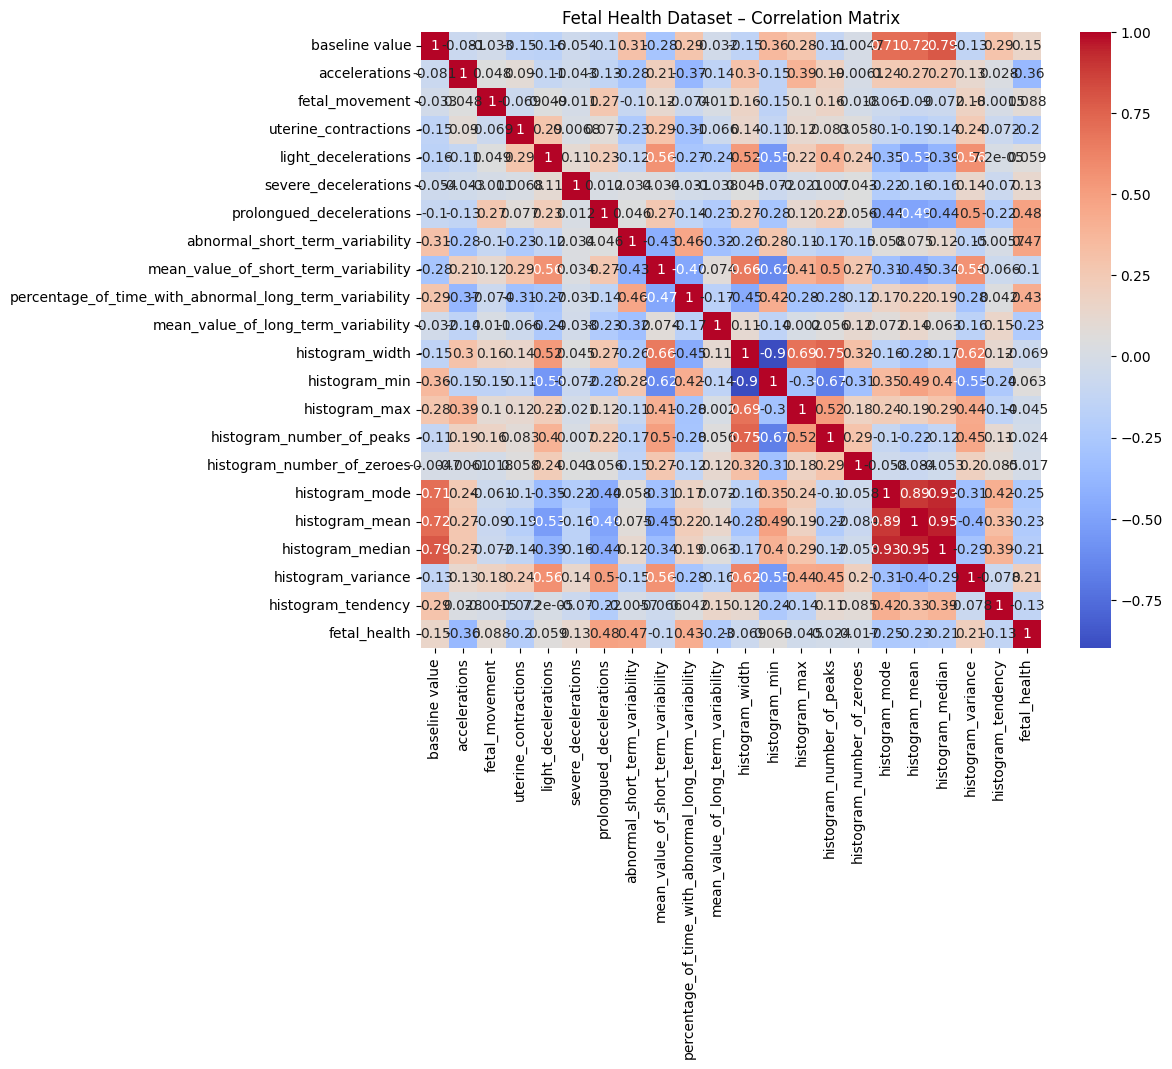


DATASET: Fetal Health Dataset

Dataset Shape: (2126, 22)

Target Distribution:
fetal_health
1.0    1655
2.0     295
3.0     176
Name: count, dtype: int64

Logistic Regression
-------------------
Accuracy: 0.8568075117370892
              precision    recall  f1-score   support

         1.0       0.99      0.86      0.92       332
         2.0       0.52      0.83      0.64        59
         3.0       0.71      0.86      0.78        35

    accuracy                           0.86       426
   macro avg       0.74      0.85      0.78       426
weighted avg       0.90      0.86      0.87       426



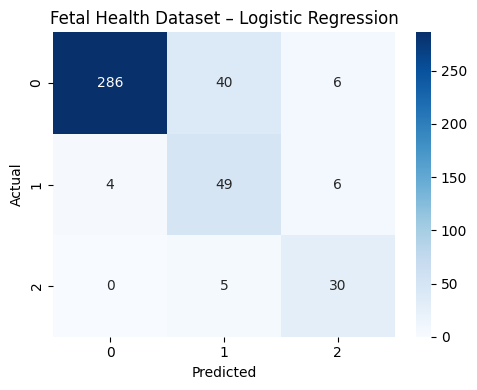


Random Forest
-------------
Accuracy: 0.931924882629108
              precision    recall  f1-score   support

         1.0       0.94      0.98      0.96       332
         2.0       0.89      0.66      0.76        59
         3.0       0.91      0.89      0.90        35

    accuracy                           0.93       426
   macro avg       0.91      0.84      0.87       426
weighted avg       0.93      0.93      0.93       426



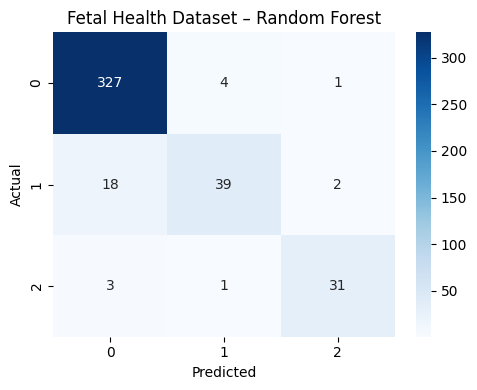


Support Vector Machine
----------------------
Accuracy: 0.8802816901408451
              precision    recall  f1-score   support

         1.0       0.99      0.89      0.94       332
         2.0       0.57      0.88      0.69        59
         3.0       0.78      0.80      0.79        35

    accuracy                           0.88       426
   macro avg       0.78      0.86      0.80       426
weighted avg       0.91      0.88      0.89       426



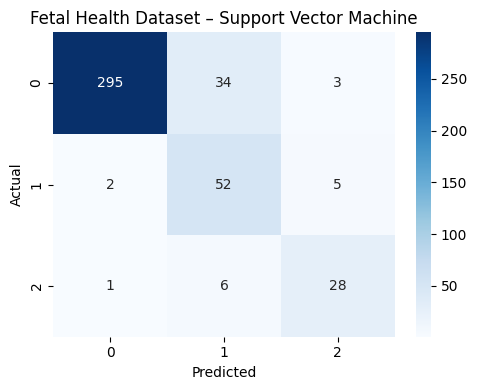


K-Nearest Neighbors
-------------------
Accuracy: 0.8708920187793427
              precision    recall  f1-score   support

         1.0       0.90      0.97      0.93       332
         2.0       0.61      0.47      0.53        59
         3.0       0.92      0.63      0.75        35

    accuracy                           0.87       426
   macro avg       0.81      0.69      0.74       426
weighted avg       0.86      0.87      0.86       426



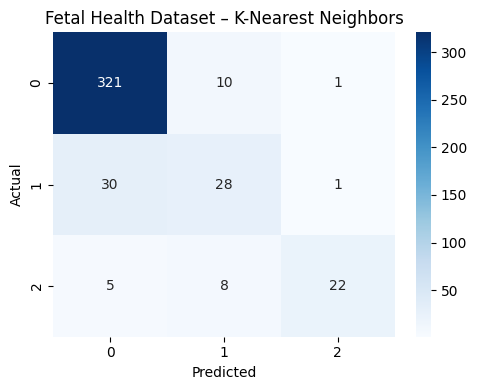

In [4]:
# Loading Fetal Health Dataset
df1 = pd.read_csv("fetal_health.csv")

# Perform EDA
perform_eda(df1, "fetal_health", "Fetal Health Dataset")

# Run ML Pipeline
run_pipeline(df1, "fetal_health", "Fetal Health Dataset")



EDA: CTG Dataset

Missing Values:
 FileName    0
Date        0
SegFile     0
b           0
e           0
LBE         0
LB          0
AC          0
FM          0
UC          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
DL          0
DS          0
DP          0
DR          0
Width       0
Min         0
Max         0
Nmax        0
Nzeros      0
Mode        0
Mean        0
Median      0
Variance    0
Tendency    0
A           0
B           0
C           0
D           0
E           0
AD          0
DE          0
LD          0
FS          0
SUSP        0
CLASS       0
NSP         0
dtype: int64

Duplicate Rows: 0


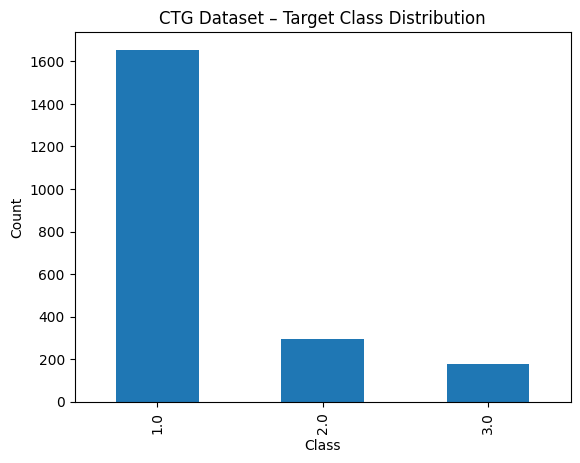

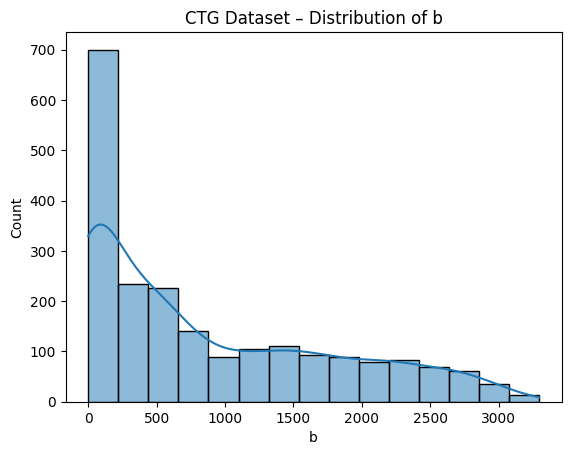

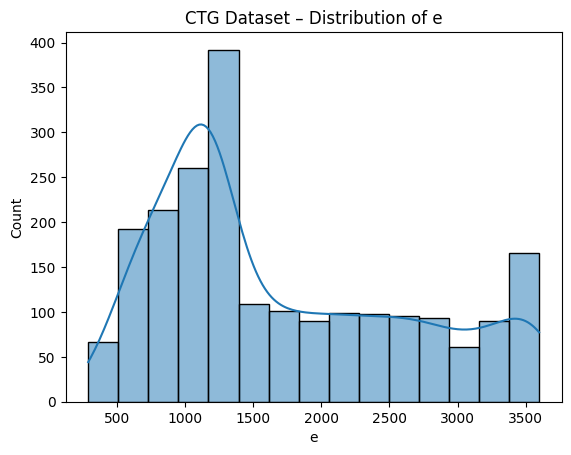

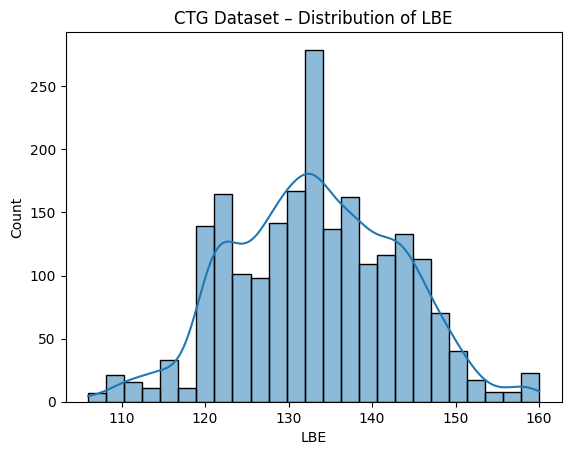

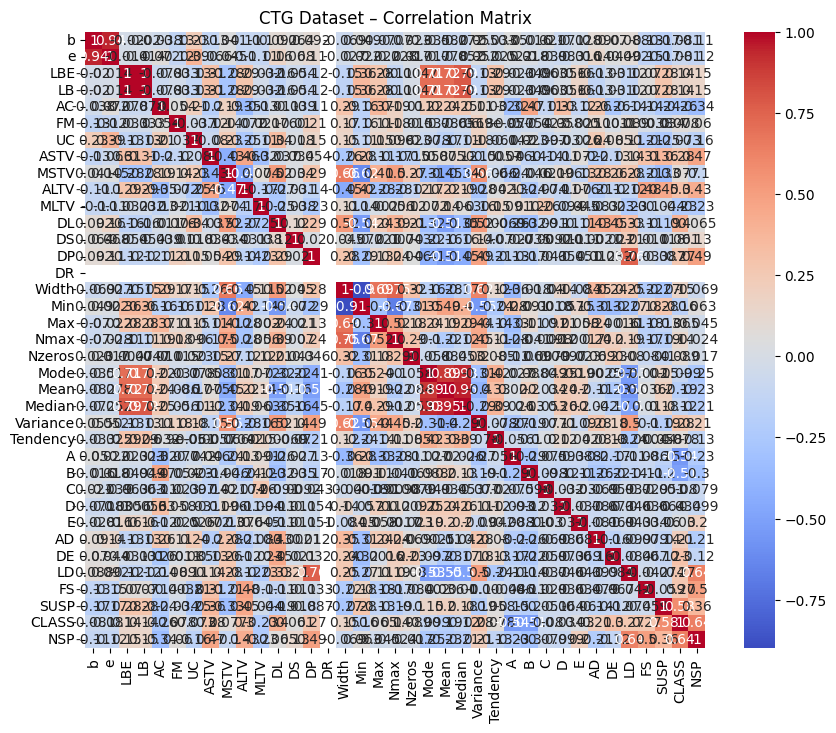


DATASET: CTG Dataset

Dataset Shape: (2126, 37)

Target Distribution:
NSP
1.0    1655
2.0     295
3.0     176
Name: count, dtype: int64

Logistic Regression
-------------------
Accuracy: 0.9859154929577465
              precision    recall  f1-score   support

         1.0       0.99      0.99      0.99       332
         2.0       0.96      0.93      0.95        59
         3.0       1.00      1.00      1.00        35

    accuracy                           0.99       426
   macro avg       0.98      0.98      0.98       426
weighted avg       0.99      0.99      0.99       426



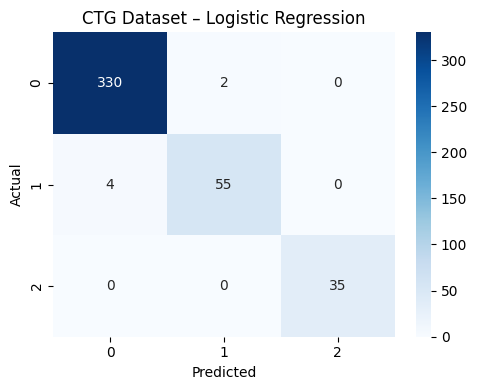


Random Forest
-------------
Accuracy: 0.9835680751173709
              precision    recall  f1-score   support

         1.0       0.98      1.00      0.99       332
         2.0       1.00      0.88      0.94        59
         3.0       1.00      1.00      1.00        35

    accuracy                           0.98       426
   macro avg       0.99      0.96      0.98       426
weighted avg       0.98      0.98      0.98       426



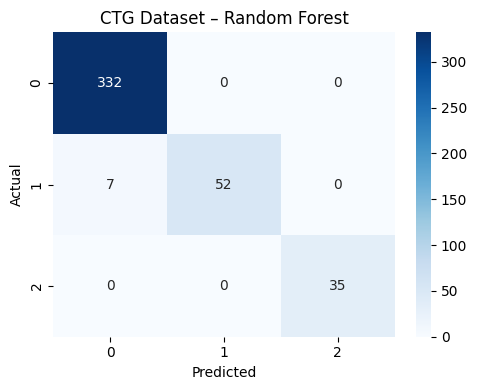


Support Vector Machine
----------------------
Accuracy: 0.9835680751173709
              precision    recall  f1-score   support

         1.0       0.99      0.99      0.99       332
         2.0       0.96      0.93      0.95        59
         3.0       0.97      1.00      0.99        35

    accuracy                           0.98       426
   macro avg       0.98      0.97      0.97       426
weighted avg       0.98      0.98      0.98       426



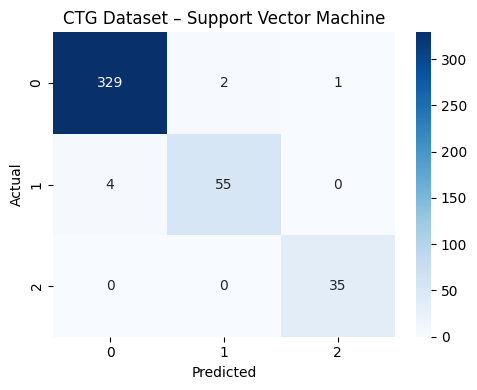


K-Nearest Neighbors
-------------------
Accuracy: 0.9765258215962441
              precision    recall  f1-score   support

         1.0       0.97      1.00      0.99       332
         2.0       1.00      0.85      0.92        59
         3.0       0.97      1.00      0.99        35

    accuracy                           0.98       426
   macro avg       0.98      0.95      0.96       426
weighted avg       0.98      0.98      0.98       426



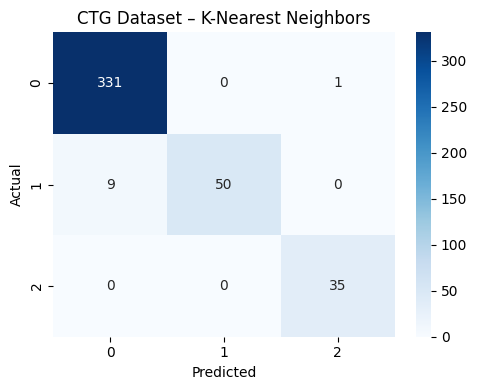

In [5]:
# Loading CTG Dataset
df2 = pd.read_csv("CTG.csv")

# Drop rows with missing target labels
df2 = df2.dropna(subset=["NSP"])

# Perform EDA
perform_eda(df2, "NSP", "CTG Dataset")

# Run ML Pipeline
run_pipeline(df2, "NSP", "CTG Dataset")
